In [2]:
from brf_lightning.utils.plot_defaults import init_plot_style

init_plot_style()

In [3]:
import numpy as np

def simulate_brf_response_numpy(
    f_carrier: float = 100.0,
    f_mod: float = 5.0,
    duration: float = 1.0,
    fs: int = 10000,
    gain: float = 4.0,
    theta: float = 0.3,
    b_offset: float = 1.5,
    mod_index: float = 0.5,
):
    dt = 1 / fs
    t = np.linspace(0, duration, int(duration * fs), endpoint=False)

    envelope = 1 + mod_index * np.sin(2 * np.pi * f_mod * t)
    signal = envelope * np.cos(2 * np.pi * f_carrier * t)
    input_current = gain * np.abs(signal)

    omega = 2 * np.pi * f_mod
    p_omega = (-1 + np.sqrt(1 - (dt * omega) ** 2)) / dt
    b = p_omega - b_offset

    u = 0.0
    v = 0.0
    q = 0.0
    spikes = []
    membrane_u = []
    q_trace = []  # NEW: record q(t)

    for x_t in input_current:
        u_new = u + b * u * dt - omega * v * dt + x_t * dt
        v_new = v + omega * u * dt + b * v * dt
        z = float(u_new > (theta + q))
        q = q * 0.9 + z

        u, v = u_new, v_new
        spikes.append(z)
        membrane_u.append(u)
        q_trace.append(q)  # record q(t)

    return t, signal, envelope, np.array(membrane_u), np.array(spikes), np.array(q_trace)


# Run the function to confirm output
t, signal, envelope, u, spikes, q_history = simulate_brf_response_numpy()


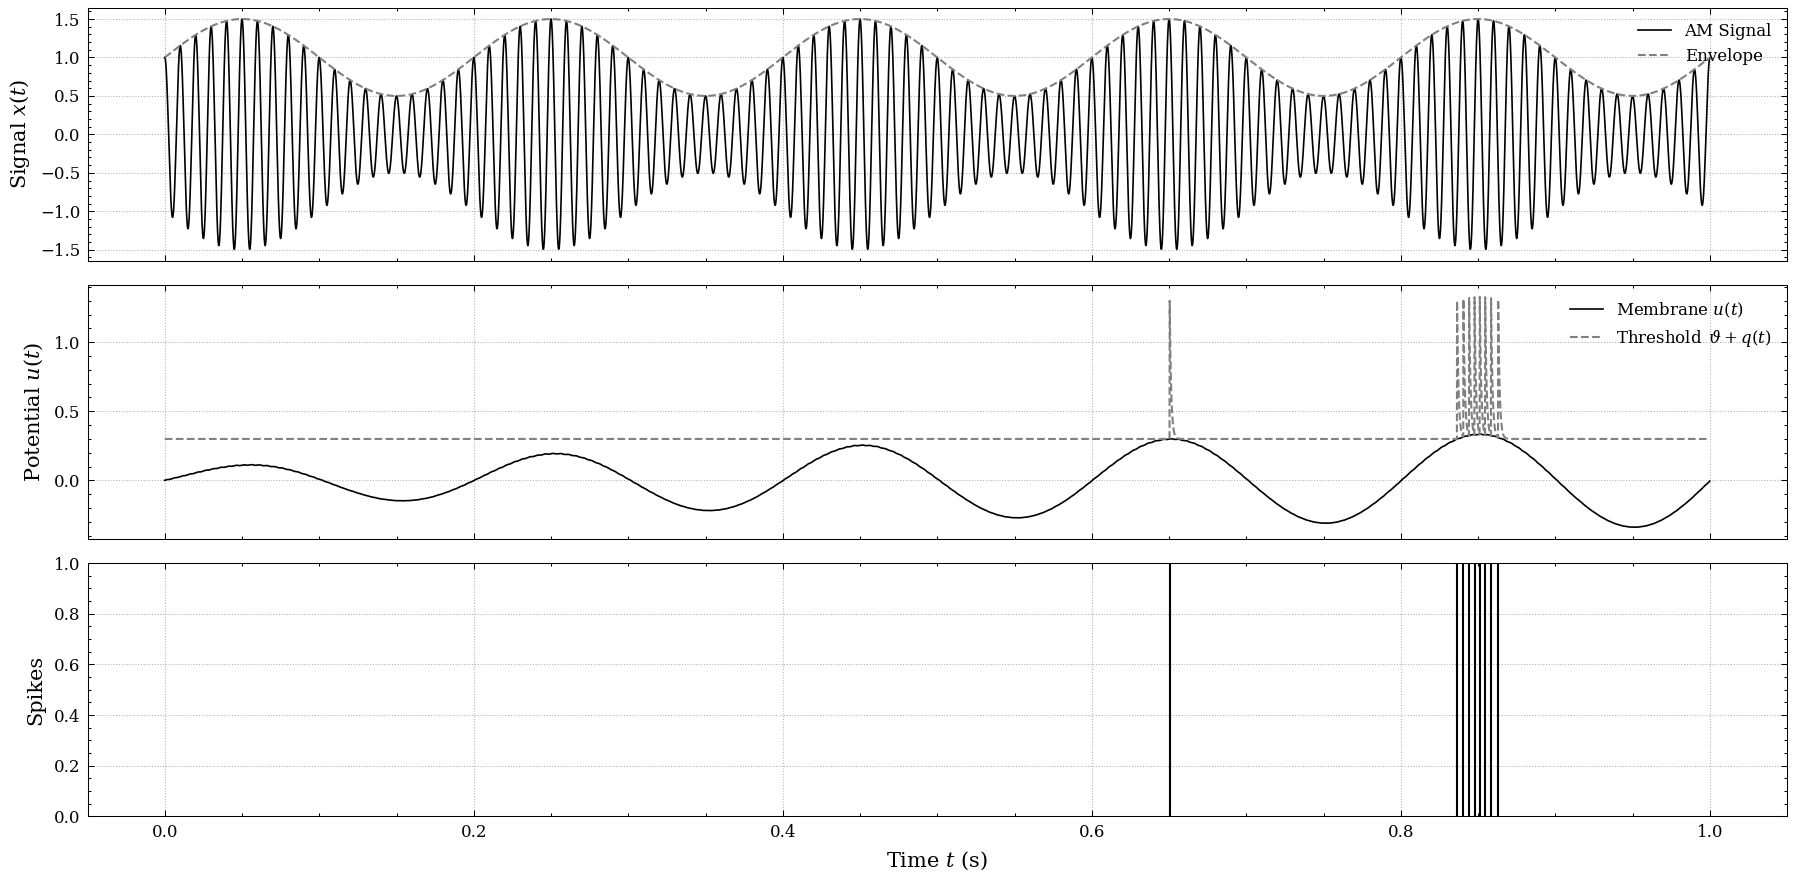

In [4]:
def plot_brf_response(
    t, signal, envelope, membrane_u, spikes, q_history,
    threshold=0.3, figsize=(12, 6)
):
    """
    Plots the BRF neuron's response, corrected to reflect threshold + q(t).

    Args:
        t: Time vector
        signal: Amplitude-modulated input signal
        envelope: Envelope of the input signal
        membrane_u: Membrane potential over time
        spikes: Spike train (binary array)
        q_history: History of refractory variable q(t)
        threshold: Baseline threshold value
        figsize: Size of the figure (default: (12, 6))
    """
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(3, 1, figsize=figsize, sharex=True)

    # Top plot: Input signal and envelope
    axs[0].plot(t, signal, label="AM Signal", color='black', linewidth=0.8)
    axs[0].plot(t, envelope, label="Envelope", color='gray', linestyle='--', linewidth=1.0)
    axs[0].set_ylabel("Signal $x(t)$")
    axs[0].legend(loc="upper right", frameon=False)
    axs[0].grid(True, linestyle=':', linewidth=0.5)

    # Middle plot: Membrane potential
    axs[1].plot(t, membrane_u, label="Membrane $u(t)$", color='black', linewidth=0.8)
    axs[1].plot(t, threshold + q_history, linestyle='--', color='gray', label=r"Threshold $\,\vartheta + q(t)$")
    axs[1].set_ylabel("Potential $u(t)$")
    axs[1].legend(loc="upper right", frameon=False)
    axs[1].grid(True, linestyle=':', linewidth=0.5)

    # Bottom plot: Spike raster
    axs[2].eventplot(t[spikes > 0], lineoffsets=0.5, colors='black')
    axs[2].set_ylim(0, 1)
    axs[2].set_ylabel("Spikes")
    axs[2].set_xlabel("Time $t$ (s)")
    axs[2].grid(True, linestyle=':', linewidth=0.5)

    for ax in axs:
        ax.tick_params(direction='in', top=True, right=True)

    plt.tight_layout()
    plt.show()


# Call plotting function
plot_brf_response(t, signal, envelope, u, spikes, q_history)


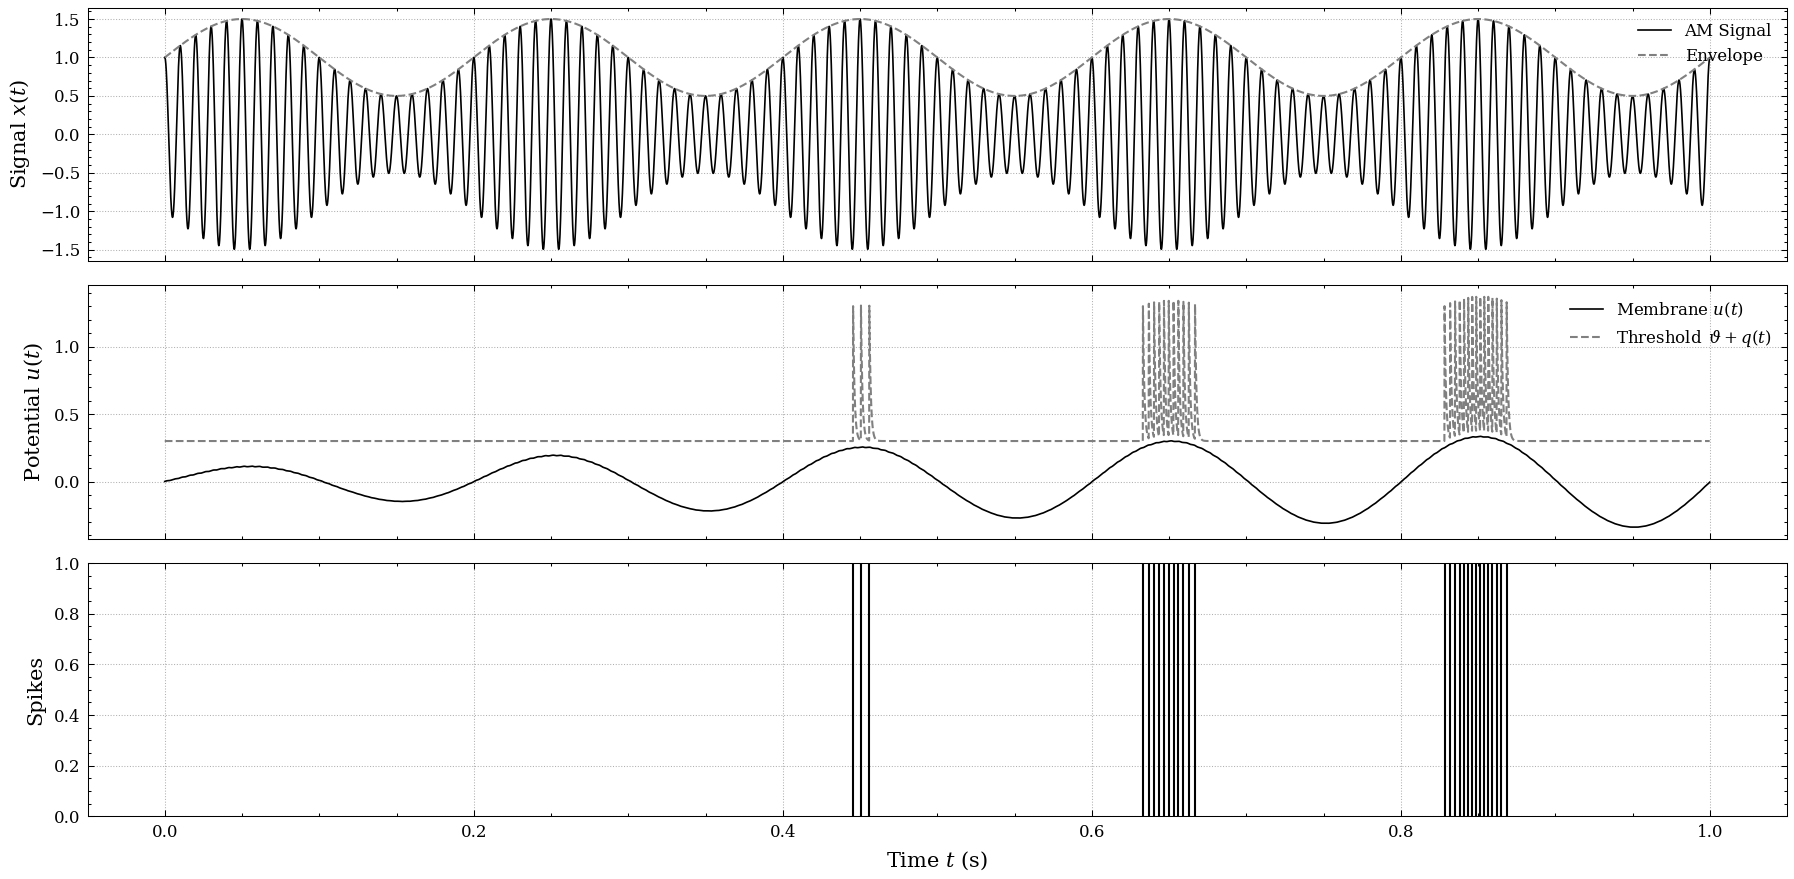

In [5]:
t, signal, envelope, u, spikes, q_history = simulate_brf_response_numpy(theta=0.25)
plot_brf_response(t, signal, envelope, u, spikes, q_history)


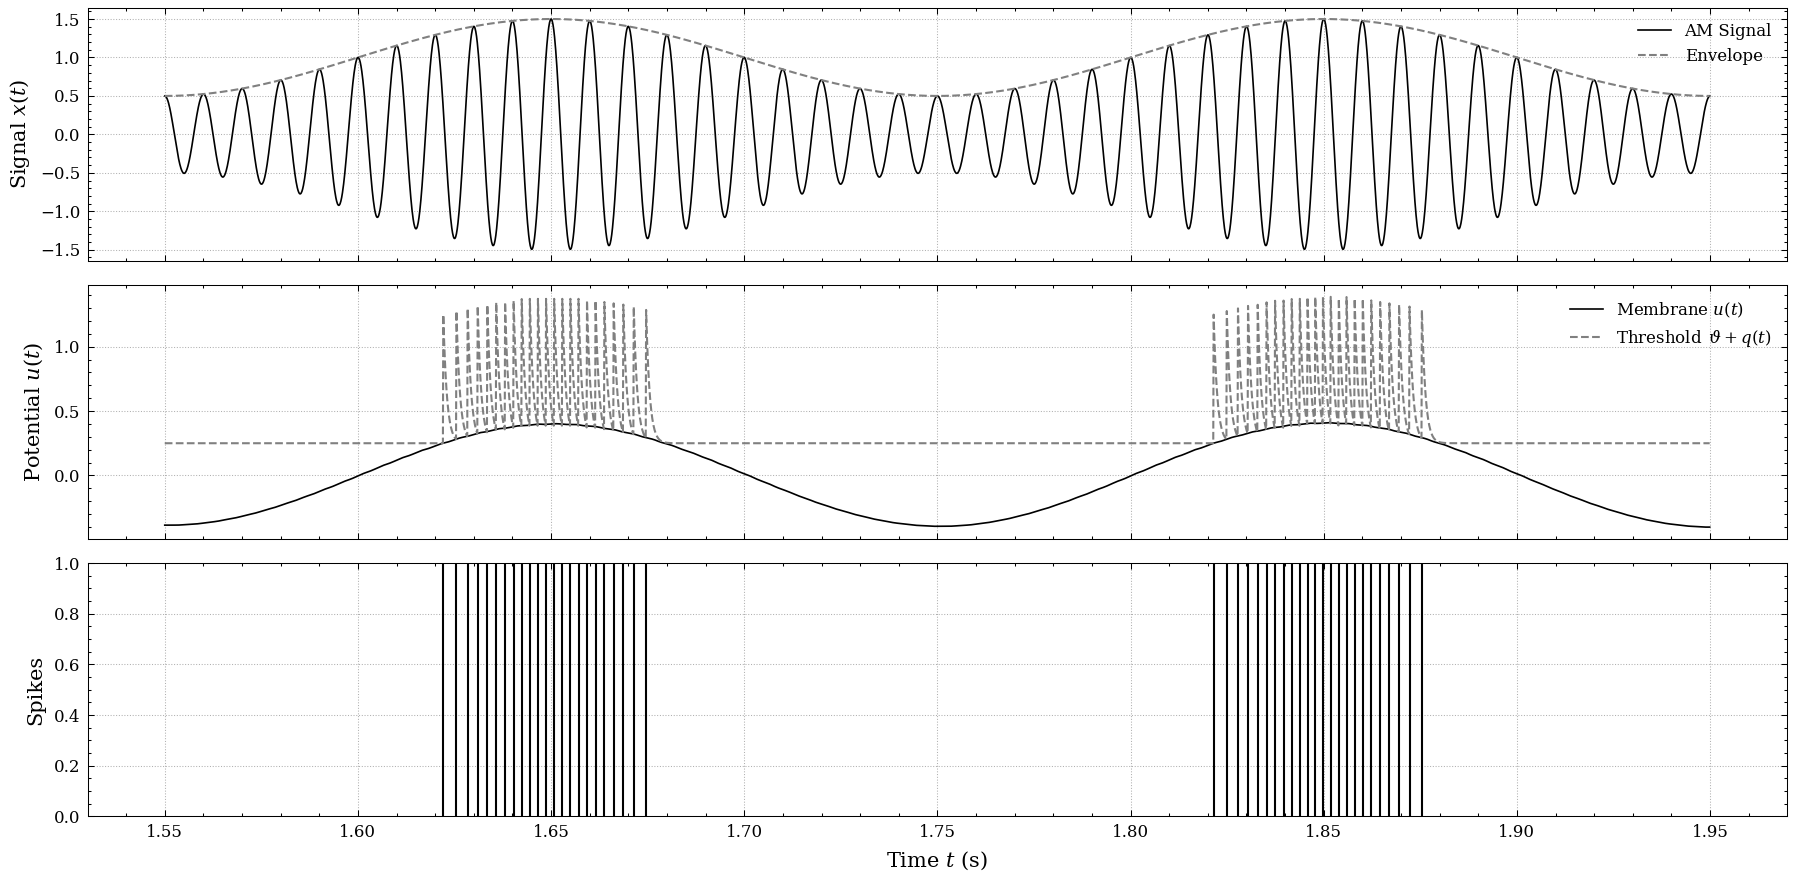

In [6]:
# Apply slicing to zoom into the stabilized part of the signal
def plot_brf_response_zoomed(
    t, signal, envelope, membrane_u, spikes, q_history,
    threshold=0.25, start_time=0.25, window=0.5
):
    """
    Zoomed-in plot of the BRF response, starting after initial transient.

    Args:
        t: Time vector
        signal: AM signal
        envelope: Envelope of the signal
        membrane_u: Membrane potential
        spikes: Spike array
        q_history: Refractory history
        threshold: Base threshold
        start_time: Time to start plotting
        window: Duration of time to plot
    """
    # Determine indices for slicing
    start_idx = np.searchsorted(t, start_time)
    end_idx = np.searchsorted(t, start_time + window)

    t_zoom = t[start_idx:end_idx]
    sig_zoom = signal[start_idx:end_idx]
    env_zoom = envelope[start_idx:end_idx]
    u_zoom = membrane_u[start_idx:end_idx]
    q_zoom = q_history[start_idx:end_idx]
    spikes_zoom = spikes[start_idx:end_idx]

    # Use the previously defined corrected plotting function
    plot_brf_response(t_zoom, sig_zoom, env_zoom, u_zoom, spikes_zoom, q_zoom, threshold=threshold)


# Generate and plot with new view
t_sim, sig_sim, env_sim, u_sim, z_sim, q_sim = simulate_brf_response_numpy(theta=0.25, duration=2.0, b_offset=1.5)
plot_brf_response_zoomed(t_sim, sig_sim, env_sim, u_sim, z_sim, q_sim, threshold=0.25, start_time=1.55, window=0.4)


/tmp/ipykernel_113858/729801026.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


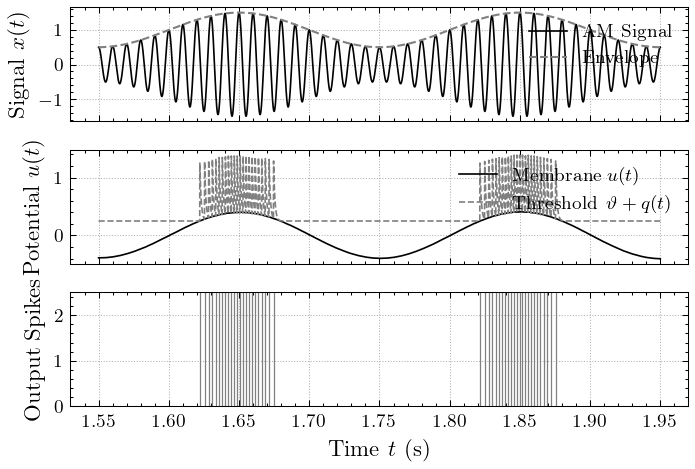

In [7]:
import matplotlib as mpl, matplotlib.pyplot as plt, numpy as np

DOC_W_PT = 426.8                            # 12 pt text width (nak.cls) in pt
FIG_W_PT = 0.9 * DOC_W_PT                  # 90 % of column width
FIG_H_PT = 0.65 * FIG_W_PT                 # ∼3:5 aspect, more vertical room
FIG_SIZE = FIG_W_PT/72.27, FIG_H_PT/72.27  # inches for figsize()

mpl.rcParams.update({
    "pgf.texsystem": "pdflatex", "text.usetex": True, "pgf.rcfonts": False,
    "font.family": "serif", "font.size": 11, "axes.labelsize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "axes.titlesize": 12, "lines.linewidth": .8,
})


def plot_brf_response_zoomed_export(
    t, signal, envelope, membrane_u, spikes, q_history,
    threshold=0.25, start_time=0.25, window=0.5,
    filename="brf_response.pgf"
):
    import numpy as np
    import matplotlib.pyplot as plt

    start_idx = np.searchsorted(t, start_time)
    end_idx = np.searchsorted(t, start_time + window)

    t_zoom = t[start_idx:end_idx]
    sig_zoom = signal[start_idx:end_idx]
    env_zoom = envelope[start_idx:end_idx]
    u_zoom = membrane_u[start_idx:end_idx]
    q_zoom = q_history[start_idx:end_idx]
    spikes_zoom = spikes[start_idx:end_idx]

    fig, axs = plt.subplots(
        3, 1, sharex=True, figsize=FIG_SIZE, gridspec_kw={"hspace": 0.25}
    ) 

    # --- Top: AM signal + envelope
    axs[0].plot(t_zoom, sig_zoom, label="AM Signal", color='black', linewidth=0.8)
    axs[0].plot(t_zoom, env_zoom, label="Envelope", color='gray', linestyle='--', linewidth=1.0)
    axs[0].set_ylabel("Signal $x(t)$")
    axs[0].legend(loc="upper right", frameon=False)
    axs[0].grid(True, linestyle=':', linewidth=0.5)

    # --- Middle: Membrane + threshold
    axs[1].plot(t_zoom, u_zoom, label="Membrane $u(t)$", color='black', linewidth=0.8)
    axs[1].plot(t_zoom, threshold + q_zoom, linestyle='--', color='gray', label=r"Threshold $\,\vartheta + q(t)$")
    axs[1].set_ylabel("Potential $u(t)$")
    axs[1].legend(loc="upper right", frameon=False)
    axs[1].grid(True, linestyle=':', linewidth=0.5)

    # --- Bottom: Spikes as vlines
    spike_times = t_zoom[spikes_zoom > 0]
    axs[2].vlines(spike_times, 0, 2.5, color="grey", lw=0.6)  # less “black bar”
    axs[2].set_ylim(0, 2.5)
    axs[2].set_ylabel("Output Spikes")
    axs[2].set_xlabel("Time $t$ (s)")
    axs[2].grid(True, linestyle=':', linewidth=0.5)

    for ax in axs:
        ax.tick_params(direction='in', top=True, right=True)

    plt.tight_layout()

    # Export to TikZ (PGFPlots)
    plt.savefig(filename)
    plt.show()


# Run and export
plot_brf_response_zoomed_export(t_sim, sig_sim, env_sim, u_sim, z_sim, q_sim, threshold=0.25, start_time=1.55, window=0.4)


In [8]:
# ------------------------------------------------------------------------
# Global Matplotlib config – matches your order-spectra settings
# ------------------------------------------------------------------------
import matplotlib as mpl, matplotlib.pyplot as plt, numpy as np

DOC_W_PT = 426.8
FIG_W_PT = 0.90 * DOC_W_PT
FIG_H_PT = 0.65 * FIG_W_PT
FIG_SIZE = (FIG_W_PT/72.27, FIG_H_PT/72.27)

mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "text.usetex": True,
    "pgf.rcfonts": False,
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.titlesize": 11,
    "lines.linewidth": .6,
})

# ------------------------------------------------------------------------
# Function that draws & exports the BRF response zoom
# ------------------------------------------------------------------------
def plot_brf_response_zoomed_export(
    t, signal, envelope, membrane_u, spikes, q_history,
    threshold=0.25, start_time=0.25, window=0.5,
    filename="dokumente/images/brf_response.pgf"
):
    """Create a three‑panel zoom‑in and export as PGF + PNG preview."""
    # ---- slice window ----------------------------------------------------
    i0, i1 = np.searchsorted(t, [start_time, start_time + window])
    tx = t[i0:i1]
    sig = signal[i0:i1]
    env = envelope[i0:i1]
    uu  = membrane_u[i0:i1]
    qq  = q_history[i0:i1]
    spike_times = tx[spikes[i0:i1] > 0]

    # ---- figure & axes ---------------------------------------------------
    fig, axs = plt.subplots(
        3, 1, sharex=True, figsize=FIG_SIZE,
        gridspec_kw={"hspace": 0.25}
    )

    # -- top: AM signal & envelope
    axs[0].plot(tx, sig,        color="steelblue", label=r"$x(t)$")
    axs[0].plot(tx, env,        color="grey", ls="--",  label="Envelope")
    axs[0].set_ylabel(r"Signal $x(t)$")
    axs[0].grid(ls=":", lw=.4)

    # -- mid: membrane & threshold
    axs[1].plot(tx, uu,         color="orange", label=r"$u(t)$")
    axs[1].plot(tx, threshold + qq, color="grey", ls=":", label=r"$\vartheta + q(t)$")
    axs[1].set_ylabel(r"Potential $u(t)$")
    axs[1].grid(ls=":", lw=.4)

    # -- bottom: spike raster
    axs[2].vlines(spike_times, 0, 1, color="grey", lw=.6)
    axs[2].set_ylim(0, 1.2)
    axs[2].set_ylabel("Spikes")
    axs[2].set_xlabel(r"Time $t$ (s)")
    axs[2].grid(ls=":", lw=.4)

    # common aesthetics
    for ax in axs:
        ax.tick_params(direction="in", top=True, right=True)

    # ---- joint legend ----------------------------------------------------
    handles, labels = [], []
    for ax in axs[:2]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h); labels.extend(l)
    fig.legend(handles, labels, ncol=len(labels),
               loc="lower center", bbox_to_anchor=(0.5, -0.08),
               frameon=False)

    # ---- layout tweaks ---------------------------------------------------
    fig.subplots_adjust(left=0.18)  # align y‑labels
    fig.tight_layout(pad=0.3)

    # ---- export PGF + PNG ------------------------------------------------
    fig.savefig(filename, bbox_inches="tight")
    fig.savefig(filename.replace(".pgf", ".png"), dpi=300)
    plt.close(fig)

    print(f"saved → {filename}")


plot_brf_response_zoomed_export(
    t_sim, sig_sim, env_sim, u_sim, z_sim, q_sim,
    threshold=0.25, start_time=1.55, window=0.4,
    filename="notebooks/thesis/plots/brf/brf_response.pgf"
)


/tmp/ipykernel_113858/689013071.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


saved → notebooks/thesis/plots/brf/brf_response.pgf


/tmp/ipykernel_113858/920624379.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


[PGF Export] Saved figure to 'notebooks/thesis/plots/brf/brf_response.pgf'.


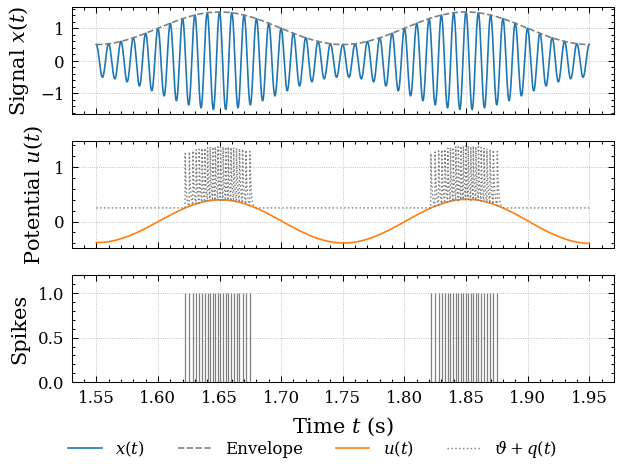

[PGF Export] Saved: notebooks/thesis/plots/brf/brf_response.pgf


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from brf_lightning.utils.plot_defaults import init_plot_style, export_figure_to_pgf

def plot_brf_response_zoomed_export(
    t, signal, envelope, membrane_u, spikes, q_history,
    threshold=0.25,
    start_time=0.25,
    window=0.5,
    filename="notebooks/thesis/plots/brf/brf_response.pgf",
    preview=True,
):
    """
    Plot the BRF neuron response over a zoomed time window and export to PGF and PNG.
    Preserves style and layout consistency with other thesis figures.
    """

    # Ensure consistent font and axis styling
    init_plot_style()
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    color_signal = colors[0]
    color_membrane = colors[1]

    # ---- slice the selected time window ----
    i0, i1 = np.searchsorted(t, [start_time, start_time + window])
    tx = t[i0:i1]
    sig = signal[i0:i1]
    env = envelope[i0:i1]
    uu = membrane_u[i0:i1]
    qq = q_history[i0:i1]
    spike_times = tx[spikes[i0:i1] > 0]

    # ---- figure setup ----
    fig, axs = plt.subplots(
        3, 1, sharex=True,
        figsize=(426.8 * 0.85 / 72.27, 426.8 * 0.55 / 72.27),
        gridspec_kw={"hspace": 0.25}
    )

    # ---- top panel: signal + envelope ----
    axs[0].plot(tx, sig, color=color_signal, linewidth=0.8, label=r"$x(t)$")
    axs[0].plot(tx, env, color="grey", ls="--", linewidth=0.8, label="Envelope")
    axs[0].set_ylabel(r"Signal $x(t)$")
    axs[0].grid(ls=":", lw=0.4)

    # ---- middle panel: membrane potential + threshold ----
    axs[1].plot(tx, uu, color=color_membrane, linewidth=0.8, label=r"$u(t)$")
    axs[1].plot(tx, threshold + qq, color="grey", ls=":", linewidth=0.7, label=r"$\vartheta + q(t)$")
    axs[1].set_ylabel(r"Potential $u(t)$")
    axs[1].grid(ls=":", lw=0.4)

    # ---- bottom panel: spikes ----
    axs[2].vlines(spike_times, 0, 1, color="grey", linewidth=0.8, lw=0.6)
    axs[2].set_ylim(0, 1.2)
    axs[2].set_ylabel("Spikes")
    axs[2].set_xlabel(r"Time $t$ (s)")
    axs[2].grid(ls=":", lw=0.4)

    # ---- common aesthetics ----
    for ax in axs:
        ax.tick_params(direction="in", top=True, right=True)

    # ---- shared legend (top + mid only) ----
    handles, labels = [], []
    for ax in axs[:2]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    fig.legend(handles, labels,
               ncol=len(labels),
               loc="lower center",
               bbox_to_anchor=(0.5, -0.08),
               frameon=False)

    # ---- spacing and alignment ----
    fig.subplots_adjust(left=0.18)
    fig.tight_layout(pad=0.3)

    # ---- export PGF and PNG ----
    export_figure_to_pgf(fig, filename)
    fig.savefig(filename.replace(".pgf", ".png"), dpi=300)

    # ---- preview in notebook ----
    if preview:
        plt.show()
    else:
        plt.close(fig)

    print(f"[PGF Export] Saved: {filename}")



plot_brf_response_zoomed_export(
    t_sim, sig_sim, env_sim, u_sim, z_sim, q_sim,
    threshold=0.25, start_time=1.55, window=0.4,
    filename="notebooks/thesis/plots/brf/brf_response.pgf"
)


## Fault Frequency Encoding



In [54]:
# Re-import necessary packages after code execution state reset
import numpy as np

def simulate_second_brf_layer(
    t,
    spike_train,
    carrier_frequency=2.5,  # now tuned to envelope frequency
    theta=0.25,
    b_offset=1.5,
    dt=0.001,
):
    """
    Simulate a second BRF neuron layer that receives spike input from a previous BRF layer.
    This layer is tuned to the envelope frequency and demonstrates resonance to input spike bursts.

    Args:
        t: time vector
        spike_train: output from previous BRF layer (binary spikes)
        carrier_frequency: frequency the BRF neuron is tuned to (Hz)
        theta: base threshold
        b_offset: damping offset
        dt: simulation time step (s)

    Returns:
        membrane_u: membrane potential u(t)
        spikes: spike array
        q_history: refractory history
    """
    omega = 2 * np.pi * carrier_frequency
    b = -omega - b_offset  # ensure negative real part for decay

    num_steps = len(t)
    u = 0.0
    v = 0.0
    q = 0.0

    u_history = np.zeros(num_steps)
    spikes = np.zeros(num_steps)
    q_history = np.zeros(num_steps)

    # inject one unit of current for each spike
    x = spike_train.astype(float)

    for i in range(num_steps):
        u_new = u + b * u * dt - omega * v * dt + x[i] * dt
        v = v + omega * u * dt + b * v * dt
        z = float((u_new - theta - q) > 0)
        q = q * 0.9 + z

        u = u_new
        spikes[i] = z
        u_history[i] = u
        q_history[i] = q

    return u_history, spikes, q_history


In [58]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# PGF export settings for LaTeX integration
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
    "font.size": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 14,
    "lines.linewidth": 1.0,
})

# Simulation function for second BRF layer
def simulate_brf_layer2(input_spikes, t, dt=0.001, omega=2 * np.pi * 2, b=2 * np.pi * 2 - 1.5, theta=0.05, scale=0.3):
    u = 0.0
    v = 0.0
    q = 0.0
    u_trace = []
    q_trace = []
    spikes = []

    for z_in in input_spikes:
        # Scaled input
        x = scale * z_in

        # BRF dynamics (same as first layer, adapted thresholding and refractory dynamics)
        u_new = u + b * u * dt - omega * v * dt + x * dt
        v = v + omega * u * dt + b * v * dt

        z = float(u_new > (theta + q))
        q = q * 0.5 + z  # faster recovery
        u = u_new

        u_trace.append(u)
        q_trace.append(q)
        spikes.append(z)

    return np.array(u_trace), np.array(spikes), np.array(q_trace)


# Plotting function for the second BRF layer
def plot_brf_layer2_response(
    t, input_spikes, membrane_u, spikes, q_history,
    threshold=0.05, start_time=1.55, window=0.4
):
    start_idx = np.searchsorted(t, start_time)
    end_idx = np.searchsorted(t, start_time + window)

    t_zoom = t[start_idx:end_idx]
    spikes_in = input_spikes[start_idx:end_idx]
    u_zoom = membrane_u[start_idx:end_idx]
    q_zoom = q_history[start_idx:end_idx]
    spikes_zoom = spikes[start_idx:end_idx]

    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axs[0].eventplot(t_zoom[spikes_in > 0], lineoffsets=0.5, colors='black', linewidths=2.0)
    axs[0].set_ylim(0, 1)
    axs[0].set_ylabel("Input Spikes")
    axs[0].grid(True, linestyle=':', linewidth=0.5)

    axs[1].plot(t_zoom, u_zoom, label="Membrane $u(t)$", color='black')
    axs[1].plot(t_zoom, threshold + q_zoom, linestyle='--', color='gray', label=r"Threshold $\vartheta + q(t)$")
    axs[1].set_ylabel("Potential $u(t)$")
    axs[1].legend(loc="upper right", frameon=False)
    axs[1].grid(True, linestyle=':', linewidth=0.5)

    axs[2].eventplot(t_zoom[spikes_zoom > 0], lineoffsets=0.5, colors='black', linewidths=2.0)
    axs[2].set_ylim(0, 1)
    axs[2].set_ylabel("Output Spikes")
    axs[2].set_xlabel("Time $t$ (s)")
    axs[2].grid(True, linestyle=':', linewidth=0.5)

    for ax in axs:
        ax.tick_params(direction='in', top=True, right=True)

    plt.tight_layout()
    plt.savefig("/mnt/data/brf_response_layer2.pgf")
    plt.show()

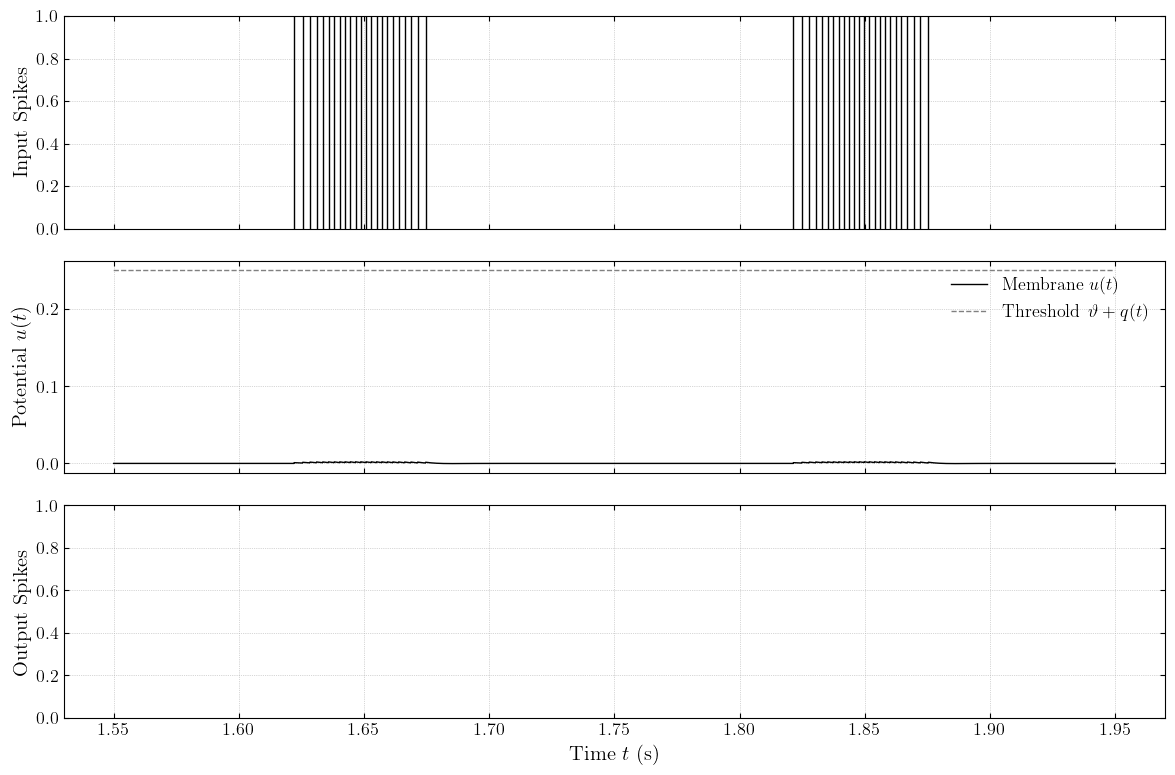

In [59]:
# simulate second layer on spike train from first
u2_sim, z2_sim, q2_sim = simulate_second_brf_layer(t_sim, z_sim, carrier_frequency=2.5)

# plot
plot_second_brf_layer(t_sim, z_sim, u2_sim, z2_sim, q2_sim)
